<a href="https://colab.research.google.com/github/GhoffarFitassin/PCVK_Ganjil_2025/blob/main/PCVKWeek6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Nama: Ghoffar Abdul Ja'far
#NIM: 2341720035
#Kelas: TI 3H

## MODUL 6 – Filter Spasial Low Pass Filter, High Pass Filter, Point Detection, Line Detection, Edge Detection

### D. PRAKTIKUM FILTER

Akses file yang terdapat pada drive dan import beberapa library yang dibutuhkan

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

Buatlah fungsi konvolusi. Catatan: parameter yang digunakan boleh dimodifikasi.
Misal, hanya menggunakan parameter image dan kernel saja, atau image, kernel, dan
padding.

In [20]:
def convolution2d(image, kernel, stride, padding):
  # Ukuran citra
  h, w = image.shape
  # Ukuran kernel
  kh, kw = kernel.shape

  # Tambahkan padding
  if padding > 0:
      padded = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')
  else:
      padded = image

  # Hitung ukuran output
  oh = (h + 2 * padding - kh) // stride + 1
  ow = (w + 2 * padding - kw) // stride + 1

  # Buat citra output
  output = np.zeros((oh, ow), dtype=np.float32)

  # Proses konvolusi manual
  for i in range(0, oh):
          for j in range(0, ow):
                  # ambil region sesuai kernel
                  region = padded[i*stride:i*stride+kh, j*stride:j*stride+kw]
                  # kalikan dan jumlahkan
                  value = np.sum(region * kernel)
                  output[i, j] = value

  # Normalisasi agar nilai tetap 0..255
  output = np.clip(output, 0, 255).astype(np.uint8)

  return output

Load citra yang akan diproses dan ubah menjadi citra keabuan

In [22]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/mandrill.tiff')
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

Tentukan kernel yang akan digunakan, contohnya kernel untuk filter sharpening
sebagai berikut:

In [23]:
#image sharpen
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])

Memanggil fungsi konvolusi yang telah dibuat sebelumnya, dan menampilkan hasil
konvolusinya:

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0, 255,   0, ..., 255, 255,   0],
       [  0, 255, 179, ..., 249, 218,   0],
       ...,
       [  0, 255, 255, ..., 159, 183,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)
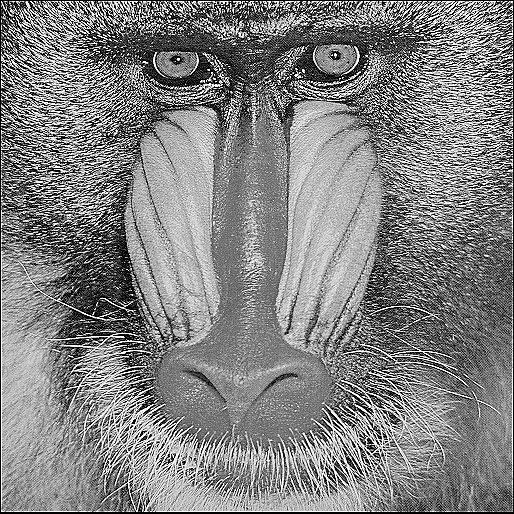

In [25]:
convolution2d(img_gray, kernel_sharpen, 1,2)

Buat Image Filter untuk Average filter, low pass filter, high pass filter, dan beberapa filter
berikut:

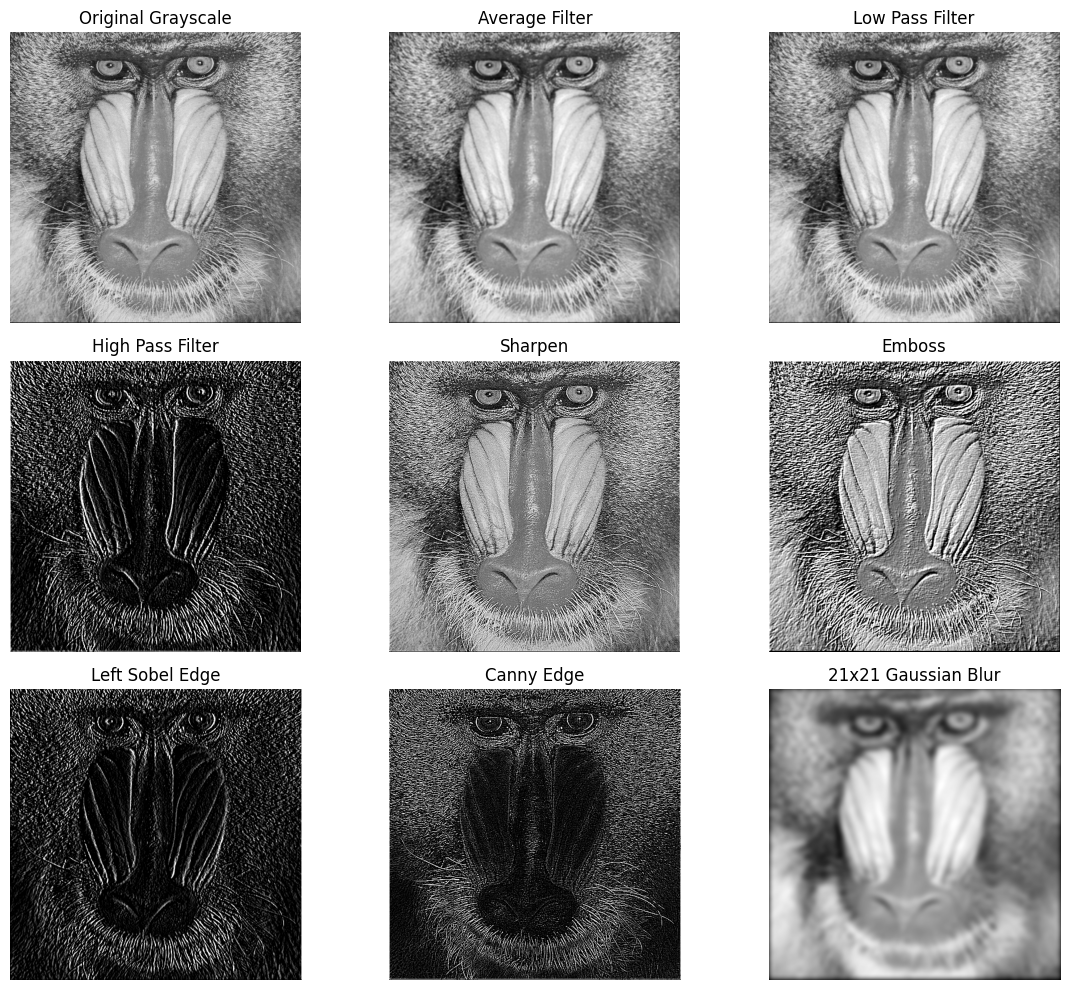

In [30]:
# =============================================================================
# BAGIAN 1: FUNGSI-FUNGSI UTAMA
# =============================================================================

def convolution2d(image, kernel, stride, padding):
    """
    Fungsi konvolusi 2D versi "implementasi praktis".
    Kode ini sesuai dengan yang Anda berikan sebelumnya.
    """
    h, w = image.shape
    kh, kw = kernel.shape

    if padding > 0:
        padded = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')
    else:
        padded = image

    oh = (h + 2 * padding - kh) // stride + 1
    ow = (w + 2 * padding - kw) // stride + 1

    output = np.zeros((oh, ow), dtype=np.float32)

    for i in range(oh):
        for j in range(ow):
            region = padded[i*stride:i*stride+kh, j*stride:j*stride+kw]
            value = np.sum(region * kernel)
            output[i, j] = value

    output = np.clip(output, 0, 255).astype(np.uint8)
    return output

def show_images(images, titles):
    """
    Fungsi untuk menampilkan beberapa gambar secara berdampingan.
    Diadaptasi dari Modul 6 - Spasial Filter.pdf, halaman 17.
    """
    plt.figure(figsize=(12, 10))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(3, 3, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# =============================================================================
# BAGIAN 2: EKSEKUSI UTAMA
# =============================================================================
try:
    # Coba muat gambar dari path yang umum di Colab
    img = cv.imread('/content/drive/MyDrive/PCVK/Images/mandrill.tiff')
    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
except Exception as e:
    # Jika gagal memuat gambar, buat gambar dummy agar kode tetap berjalan
    print(f"Gagal memuat gambar, membuat gambar dummy. Error: {e}")
    img_gray = np.zeros((256, 256), dtype=np.uint8)
    cv.putText(img_gray, 'Gambar Tidak Ditemukan', (20, 128), cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)


# --- Mendefinisikan Semua Kernel dari Tugas ---

kernel_avg = np.ones((3, 3), np.float32) / 9
kernel_lowpass = np.array([[1, 1, 1], [1, 4, 1], [1, 1, 1]], np.float32) / 12
kernel_highpass = np.array([[-1, 0, 1], [-1, 0, 3], [-3, 0, 1]], np.float32)
kernel_sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], np.float32)
kernel_emboss = np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]], np.float32)
kernel_left_sobel = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], np.float32)
kernel_canny = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], np.float32)

# Membuat kernel Gaussian 21x21
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel_1d = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian_21x21 = gaussian_kernel_1d @ gaussian_kernel_1d.transpose()


# --- Menerapkan Filter ke Citra ---
# Stride=1, Padding=1 untuk kernel 3x3 agar ukuran tetap sama
# Padding=10 untuk kernel 21x21 ( (21-1)/2 )
output_avg = convolution2d(img_gray, kernel_avg, 1, 1)
output_lowpass = convolution2d(img_gray, kernel_lowpass, 1, 1)
output_highpass = convolution2d(img_gray, kernel_highpass, 1, 1)
output_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 1)
output_emboss = convolution2d(img_gray, kernel_emboss, 1, 1)
output_left_sobel = convolution2d(img_gray, kernel_left_sobel, 1, 1)
output_canny = convolution2d(img_gray, kernel_canny, 1, 1)
output_gaussian_21x21 = convolution2d(img_gray, kernel_gaussian_21x21, 1, 10)


# --- Menampilkan Hasil ---
images_to_show = [
    img_gray, output_avg, output_lowpass, output_highpass,
    output_sharpen, output_emboss, output_left_sobel,
    output_canny, output_gaussian_21x21
]
titles_for_show = [
    'Original Grayscale', 'Average Filter', 'Low Pass Filter', 'High Pass Filter',
    'Sharpen', 'Emboss', 'Left Sobel Edge',
    'Canny Edge', '21x21 Gaussian Blur'
]

show_images(images_to_show, titles_for_show)

E. FILTER LIBRARY DAN FILTER MODERN

Percobaan 1:
Pada percobaan 1 ini, kita akan membuat Filter Gaussian, Sharpen, dan Canny menggunakan library
filter2d dari OpenCV. Filter ini akan kita terapkan pada Image RGB. Pada bagian awal kode terdapat
fungsi show_side_by_side yang digunakan untuk menampilkan gambar secara berdampingan.

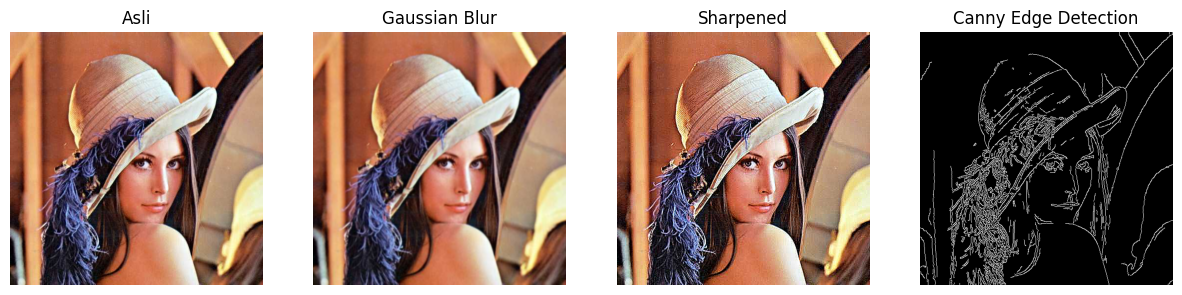

In [33]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2: # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else: # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/drive/MyDrive/PCVK/Images/lena.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

Percobaan 2:
Pada percobaan 2 berikut ini akan dilakukan filtering modern dari Library OpenCV. Dua filter yang akan digunakan adalah *Bilateral Filtering* dan Guided Filter.

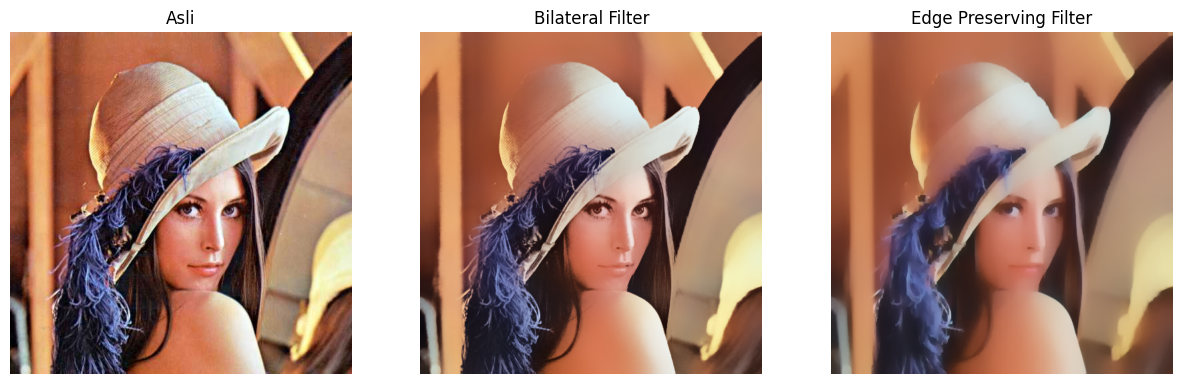

In [34]:
# Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

Percobaan 3:
Percobaan kali ini akan mencoba melihat proses Filtering pada CNN (bagian Feature Map), lakukan running code beberapa kali dan perhatikan hasil outputnya. Apa yang dapat kamu simpulkan dari hasil keluaran tersebut.

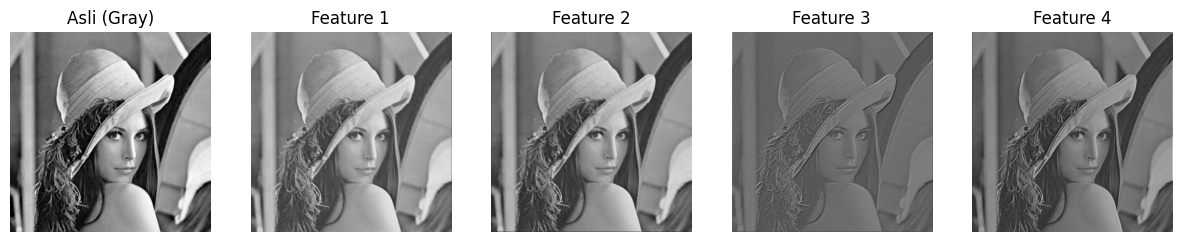

In [35]:
#Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

Percobaan 4:
Percobaan kali ini akan melakukan efek Beauty dan Vintage yang biasanya digunakan pada Aplikasi popular saat ini. Filter yang digunakan merupakan kombinasi dari filter tradisional. Perlu diketahui untuk filter aplikasi popular bisa jadi tidak menggunakan metode yang sama. Pada Aplikasi popular bisa jadi menggunakan model GenAI dengan data Training untuk memberikan hasil yang lebih akurat.

In [36]:
# ================
# 1. Beauty Filter
# ================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2 # contrast
beta = 15   # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# ======================
# 2. Old/Vintage Filter
# ======================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

Percobaan 5 akan menunjukkan pada anda filter anime / cartoon menggunakan kombinasi filter tradisional.

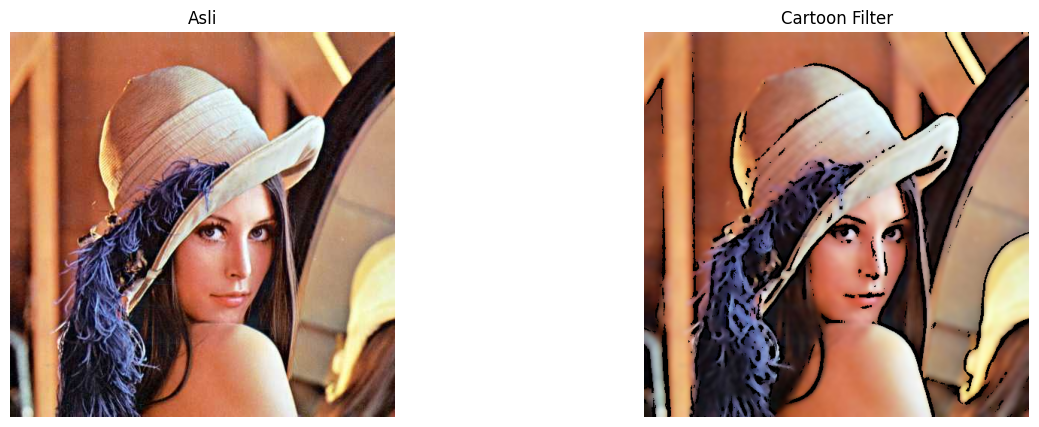

In [37]:
#Filter Anime / Cartoon
#Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                            cv.ADAPTIVE_THRESH_MEAN_C,
                            cv.THRESH_BINARY, 9, 9)

#Step 2: Bilateral Filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

#Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

In [ ]:
Percobaan 6:
Pada Percobaan 6 akan ditunjukkan contoh Filter Malam.

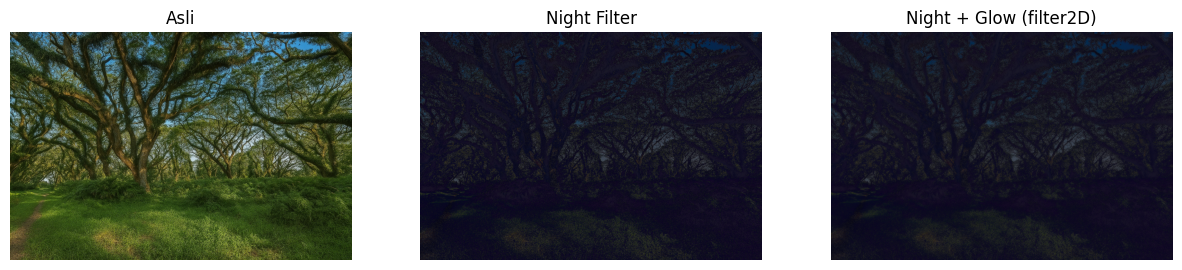

In [38]:
#Night Filter
img = cv.imread("/content/drive/MyDrive/PCVK/Images/djawatan.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

#Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

#Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 0)) # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

#Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32)/225
glow = cv.filter2D(night, -1, kernel)

#Kombinasi antara asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

Percobaan 7
Percobaan 7 menunjukkan Filter Pagi dan Pagi ditambahkan efek kabut.

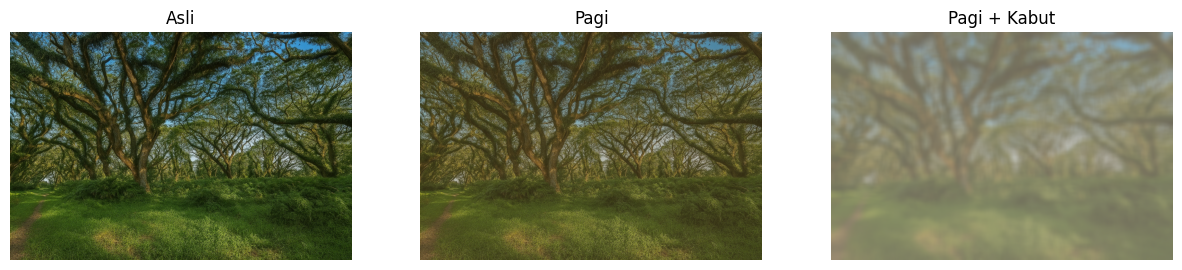

In [39]:
#Filter Suasana pagi dan Kabut
# ==============================
# Step 1: Kurangi kontras & cerahkan
# ==============================
alpha = 0.9 # contrast
beta = 20   # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# ==============================================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# ==============================================
warm_tint = np.full_like(soft, (0, 70, 120)) # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# ==============================================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# ==============================================
# Kernel blur Gaussian-Like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(31, 31)
kernel = kernel @ kernel.T # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah Layer putih untuk kabut Lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])